In [1]:
import sys
# !{sys.executable} -m pip install gensim pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim import corpora, models
from gensim.models import Phrases
from gensim.models.coherencemodel import CoherenceModel
import re

print("✅ Bibliotheken geladen.")

/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✅ Bibliotheken geladen.


In [10]:
# Daten einlesen
df = pd.read_csv('Urteile_Bereinigt.csv')

# --- VOLLSTÄNDIGE STOPPWORTLISTE ---
stop_list = [
    # Prozessuale Rollen & Bezeichnungen
    'urteil', 'datum', 'beschluss', 'entscheidung', 'senat', 'bundesgerichtshof', 'bgh', 'eugh',
    'gerichtshof', 'revision', 'berufung', 'kläger', 'beklagte', 'klägerin', 'beklagter',
    'anhängig', 'anhängigkeit', 'vorbring', 'vorbringen', 'erfolg', 'feststellung',
    'landgericht', 'berufungsgericht', 'olg', 'strafkammer', 'angeklagter', 'verurteilung',
    'richter', 'rechtssache', 'vorabentscheidung', 'schlussantrag', 'generalanwalt',
    'vorlageverfahren', 'tenor', 'rs', 'ecli', 'grur', 'njw', 'bghz', 'beckrs', 'beck', 'mwn',
    'juris', 'nrr', 'rra', 'nzm', 'lrz', 'zins', 'kosten', 'streitwert', 'euro', 
    'person', 'maßnahme', 'bestimmung', 'partei', 'beklagt', 'fassung', 'wrp', 'gericht', 
    'verfahren', 'anspruch', 'rechtsprechung', 'bgb', 'vom', 'antragsteller', 'beschluß', 
    'vorschrift', 'artikel', 'parlament', 'rat', 'kommission', 'fall', 'sache', 
    'grundsatz', 'voraussetzung', 'tatsache', 'erzeugnis', 'gebiet', 
    'bundespatentgericht', 'notar', 'patentanwaltsbewerber', 'beispiel', 
    'hinsicht', 'bezug', 'buchst', 'ziffer', 'randnummer', 'absatz', 'paragraf',
    'gründe', 'tatbestand', 'entscheidungsgründe', 'streitig', 'vortrag', 'beweis', 
    
    # Zeitliche & Generische Füllwörter
    'januar', 'februar', 'märz', 'april', 'mai', 'juni', 'juli', 'august', 
    'september', 'oktober', 'november', 'dezember', 'jahr', 'tag', 'zeitpunkt',
    'zeitraum', 'frist', 'ablauf', 'mitteilung', 'heute', 'damalig', '2020', '2021', '2022', '2023', '2024', '2025',
    'sowie', 'beziehungsweise', 'nebst', 'hinsichtlich', 'muss', 'sollen', 'lassen',
    'teil', 'art', 'weise', 'grundlage', 'zweck', 'ziel', 'gegenstand', 'inhalt',
    'republik', 'mitgliedstaat', 'union', 'eu', 'land', 'königreich', 'hoheitsgebiet',
    
    # Fragmente & Instanzen
    'rdigung', 'hrung', 'ndung', 'igkeit', 'tigkeit', 'tigkei', 'nkung', 'rderung',
    'beh', 'rde', 'versto', 'vorbringung', 'bef', 'nr', 'abl', 'abs', 'art', 'xii', 'viii',
]

# Vorbereitung der Dokumente
docs = [str(text).split() for text in df['Text_Nomen'].fillna('')]
tokenized_docs = [[w for w in doc if len(w) > 3 and w.lower() not in stop_list] for doc in docs]

# Bigrams (Schwellenwert erhöht für höhere Präzision)
bigram = Phrases(tokenized_docs, min_count=10, threshold=50)
cleaned_docs = [bigram[doc] for doc in tokenized_docs]

# Dictionary & Korpus (Balance-Filter)
id2word = corpora.Dictionary(cleaned_docs)
id2word.filter_extremes(no_below=3, no_above=0.5) 
corpus = [id2word.doc2bow(text) for text in cleaned_docs]

print(f"✅ Korpus mit {len(id2word)} Begriffen bereit.")

✅ Korpus mit 4479 Begriffen bereit.


In [11]:
# LDA Modellierung
lda_gensim = models.LdaModel(
    corpus=corpus, 
    id2word=id2word, 
    num_topics=6, 
    random_state=42, 
    passes=30,          # Mehr Durchläufe für bessere Konvergenz
    iterations=500,     # Höhere Rechenintensität pro Dokument
    alpha='auto', 
    eta='auto'
)

# Coherence Score
coherence_model = CoherenceModel(model=lda_gensim, texts=cleaned_docs, dictionary=id2word, coherence='c_v')
print(f'🚀 Neuer Coherence Score ($C_v$): {coherence_model.get_coherence():.4f}')

# Themen-Inhalte ausgeben
for idx, topic in lda_gensim.print_topics(-1):
    print(f"Thema {idx}: {topic}\n")

/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' mod

🚀 Neuer Coherence Score ($C_v$): 0.5022
Thema 0: 0.024*"Beihilfe" + 0.020*"AEUV" + 0.017*"Verordnung" + 0.017*"StGB" + 0.014*"Unternehmen" + 0.010*"Ryanair" + 0.010*"Flug" + 0.010*"Fluggast" + 0.009*"Schaden" + 0.007*"Rechtsfehler"

Thema 1: 0.043*"reisend" + 0.042*"Reise" + 0.028*"Richtlinie" + 0.027*"651h" + 0.023*"Pauschalreise" + 0.022*"Reiseveranstalter" + 0.019*"Pauschalreisevertrag" + 0.017*"Rücktritt" + 0.013*"Erstattung" + 0.013*"Beeinträchtigung"

Thema 2: 0.013*"Leistung" + 0.012*"Mieter" + 0.011*"Aufl" + 0.008*"Miete" + 0.008*"Senatsurteil" + 0.007*"Wohnungseigentümer" + 0.006*"Kündigung" + 0.006*"Störung_Geschäftsgrundlage" + 0.006*"Ausbildung" + 0.006*"Mietsache"

Thema 3: 0.080*"Richtlinie" + 0.013*"Arbeitnehmer" + 0.013*"Verstoß" + 0.013*"AEUV" + 0.012*"Verpflichtung" + 0.012*"Umsetzung" + 0.011*"Verordnung" + 0.010*"Gesetz" + 0.008*"Unionsrecht" + 0.007*"Schutz"

Thema 4: 0.039*"Verordnung" + 0.022*"Verarbeitung" + 0.022*"DSGVO" + 0.022*"Schutz" + 0.012*"Antrag" + 0.01

In [15]:
def get_dominant_topic(model, corpus):
    topic_list = []
    for doc_dist in model[corpus]:
        prob_list = doc_dist[0] if isinstance(doc_dist, tuple) else doc_dist
        sorted_probs = sorted(prob_list, key=lambda x: x[1], reverse=True)
        topic_list.append(sorted_probs[0][0])
    return topic_list

df['Dominant_Topic'] = get_dominant_topic(lda_gensim, corpus)

# Mapping
topic_names = {
    0: "Unionsrecht & Beihilfen",
    1: "Pauschalreiserecht",
    2: "Gewerbemiete & § 313 BGB",
    3: "Richtlinien & Arbeitnehmer",
    4: "Datenschutz & DSGVO",
    5: "Infektionsschutz & IfSG"
}
df['Topic_Label'] = df['Dominant_Topic'].map(topic_names)

print("✅ Themen zugeordnet.")

✅ Themen zugeordnet.


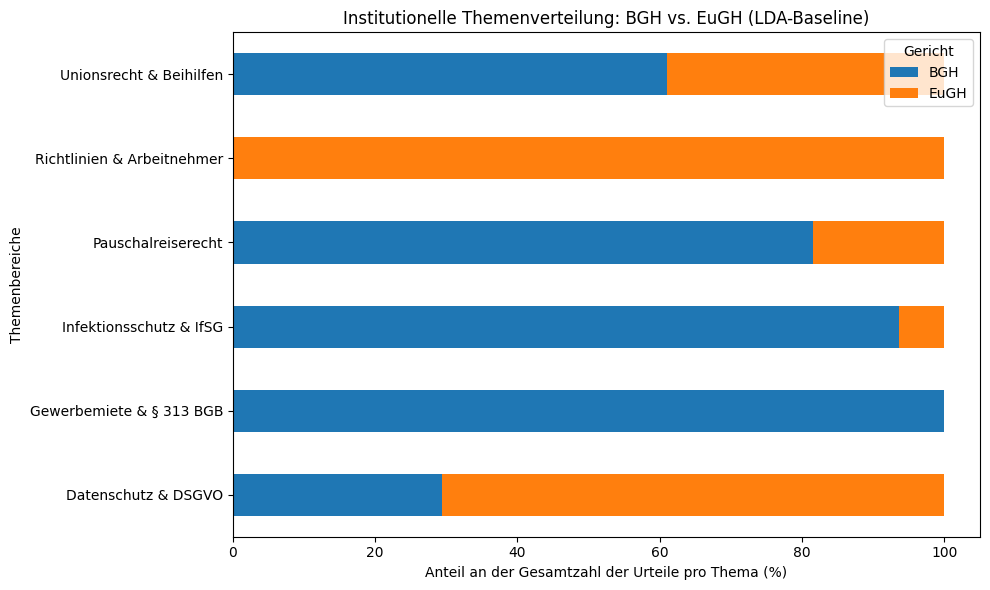

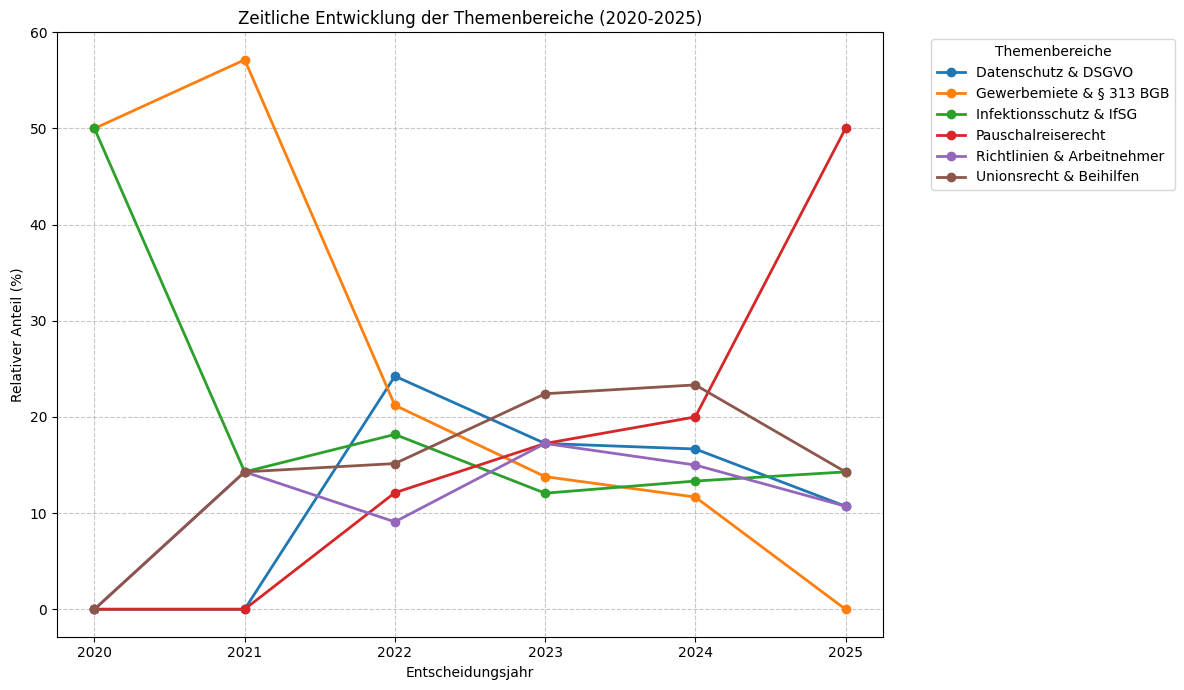

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot 1: Gerichtsvergleich
# Wir nutzen weiterhin die existierende Spalte 'Topic_Label' für die Berechnung
pivot_gericht = pd.crosstab(df['Topic_Label'], df['Gericht'], normalize='index') * 100

# Grafik erstellen
ax1 = pivot_gericht.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])

# Beschriftungen anpassen
plt.title('Institutionelle Themenverteilung: BGH vs. EuGH (LDA-Baseline)')
plt.xlabel('Anteil an der Gesamtzahl der Urteile pro Thema (%)')
plt.ylabel('Themenbereiche') # <--- Hier wird "Topic_Label" durch "Themenbereiche" ersetzt

plt.tight_layout()
plt.savefig('Gerichtsvergleich.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Zeitstrahl
evolution = df.groupby(['Jahr', 'Topic_Label']).size().unstack(fill_value=0)
evolution_pct = evolution.div(evolution.sum(axis=1), axis=0) * 100

# Grafik erstellen
ax2 = evolution_pct.plot(kind='line', marker='o', figsize=(12, 7), linewidth=2)

# Beschriftungen anpassen
plt.title('Zeitliche Entwicklung der Themenbereiche (2020-2025)')
plt.ylabel('Relativer Anteil (%)')
plt.xlabel('Entscheidungsjahr')
plt.grid(True, linestyle='--', alpha=0.7)

# Die Legende bekommt einen sauberen Titel statt "Topic_Label"
plt.legend(title='Themenbereiche', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('Zeitstrahl.png', dpi=300, bbox_inches='tight')
plt.show()